In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Railway_info.csv")


In [2]:
print(df.head())

   Train_No    Train_Name Source_Station_Name  \
0       107  SWV-MAO-VLNK     SAWANTWADI ROAD   
1       108  VLNK-MAO-SWV         MADGOAN JN.   
2       128  MAO-KOP SPEC         MADGOAN JN.   
3       290  PALACE ON WH   DELHI-SAFDAR JANG   
4       401  BSB BHARATDA          AURANGABAD   

             Destination_Station_Name       days  
0                         MADGOAN JN.   Saturday  
1                     SAWANTWADI ROAD     Friday  
2  CHHATRAPATI SHAHU MAHARAJ TERMINUS     Friday  
3                   DELHI-SAFDAR JANG  Wednesday  
4                        VARANASI JN.   Saturday  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Train_No                  11113 non-null  int64 
 1   Train_Name                11113 non-null  object
 2   Source_Station_Name       11113 non-null  object
 3   Destination_Station_Name  11113 non-null  object
 4   days                      11113 non-null  object
dtypes: int64(1), object(4)
memory usage: 434.2+ KB
None


In [4]:
print(df.isnull().sum())

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


In [5]:
print("Total trains:", len(df))

Total trains: 11113


In [7]:
print("Unique source stations:",
      df['Source_Station_Name'].nunique())

Unique source stations: 921


In [8]:
print("Unique destination stations:",
      df['Destination_Station_Name'].nunique())

Unique destination stations: 924


In [9]:
print("Most common source:",
      df['Source_Station_Name'].value_counts().idxmax())

Most common source: CST-MUMBAI


In [10]:
print("Most common destination:",
      df['Destination_Station_Name'].value_counts().idxmax())

Most common destination: CST-MUMBAI


In [11]:
# Handle missing values
df = df.dropna() 


In [15]:
# Standardize station names
df['Source_Station_Name'] = df['Source_Station_Name'].str.upper()
df['Destination_Station_Name'] = df['Destination_Station_Name'].str.upper()

In [14]:
df.groupby('Source').size()


Source
ABHANPUR JN.       2
ABOHAR             1
ABU ROAD           1
ACHHNERA JN.       1
ADILABAD           5
                  ..
WARASEONI          1
WARDHA JN.         4
WHITE FIELD        2
YAMUNA BRIDGE      2
YESVANTPUR JN.    60
Length: 921, dtype: int64

In [17]:
df.groupby(['Source','days']).size().groupby('Source').mean()


Source
ABHANPUR JN.      1.000000
ABOHAR            1.000000
ABU ROAD          1.000000
ACHHNERA JN.      1.000000
ADILABAD          1.250000
                    ...   
WARASEONI         1.000000
WARDHA JN.        1.000000
WHITE FIELD       1.000000
YAMUNA BRIDGE     1.000000
YESVANTPUR JN.    8.571429
Length: 921, dtype: float64

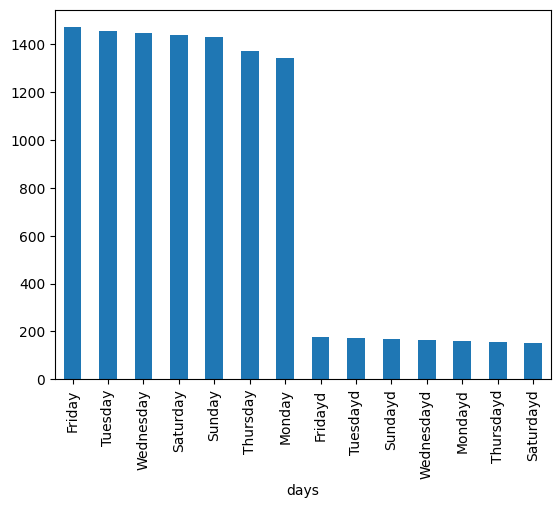

In [18]:
import matplotlib.pyplot as plt

df['days'].value_counts().plot(kind='bar')
plt.show()


In [19]:
df.groupby('days').size()

days
Friday        1471
Fridayd        178
Monday        1342
Mondayd        161
Saturday      1441
Saturdayd      152
Sunday        1432
Sundayd        170
Thursday      1372
Thursdayd      154
Tuesday       1454
Tuesdayd       174
Wednesday     1448
Wednesdayd     164
dtype: int64

In [22]:
df['Route'] = df['Source_Station_Name'] + " → " + df['Destination_Station_Name']

df['Route'].value_counts().head(10)


Route
CHENNAI BEACH → TAMBARAM      137
TAMBARAM → CHENNAI BEACH      137
CST-MUMBAI → PANVEL            94
PANVEL → CST-MUMBAI            93
RAVLI JN → CST-MUMBAI          90
CST-MUMBAI → RAVLI JN          90
VELACHEERY → CHENNAI BEACH     89
CHENNAI BEACH → VELACHEERY     87
CST-MUMBAI → THANE             77
THANE → CST-MUMBAI             72
Name: count, dtype: int64

<Axes: xlabel='Route'>

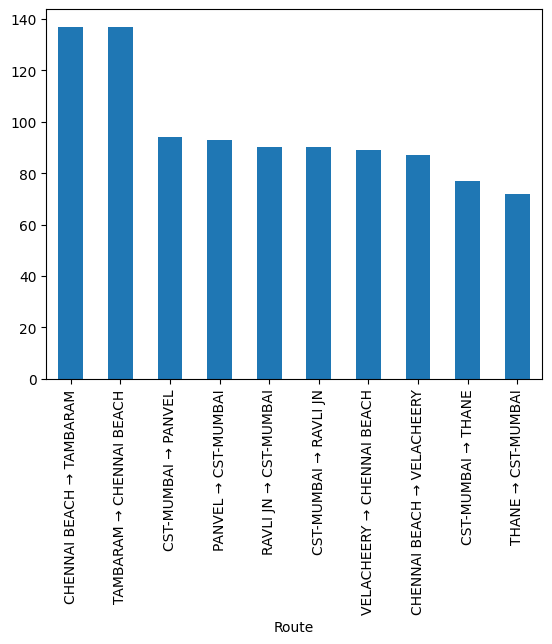

In [23]:
df['Route'].value_counts().head(10).plot(kind='bar')


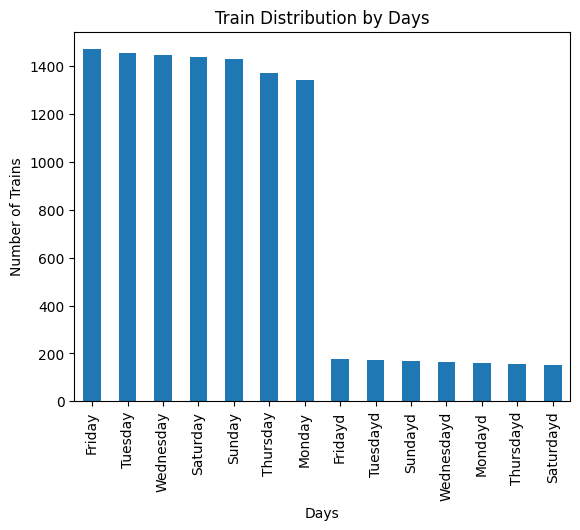

In [24]:


df['days'].value_counts().plot(kind='bar')
plt.title("Train Distribution by Days")
plt.xlabel("Days")
plt.ylabel("Number of Trains")
plt.show()


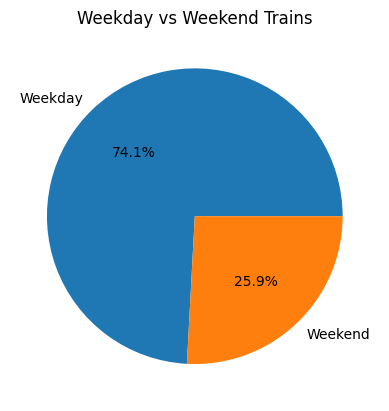

In [25]:
weekend = ['Saturday','Sunday']
df['Category'] = df['days'].apply(
    lambda x: 'Weekend' if x in weekend else 'Weekday'
)

df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Weekday vs Weekend Trains")
plt.ylabel("")
plt.show()


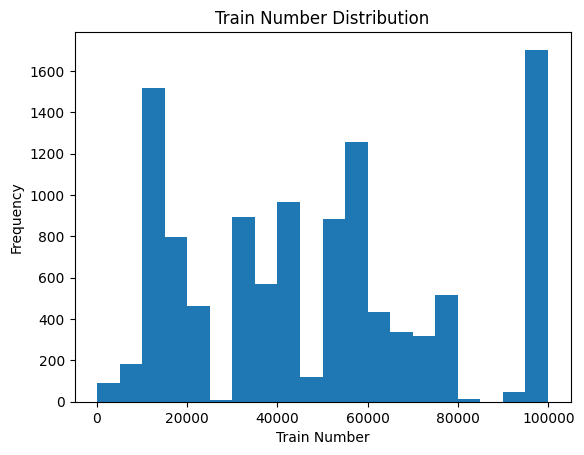

In [26]:
df['Train_No'].plot(kind='hist', bins=20)
plt.title("Train Number Distribution")
plt.xlabel("Train Number")
plt.show()


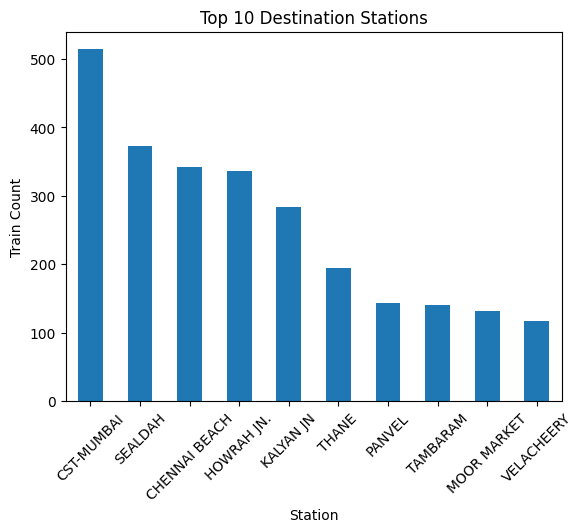

In [27]:
df['Destination_Station_Name'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Destination Stations")
plt.xlabel("Station")
plt.ylabel("Train Count")
plt.xticks(rotation=45)
plt.show()
